# Projet Covid19 : Exploration des données

## 1. Présentation du dataset

Ce projet utilise le dataset COVID-19 Radiography Dataset : https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database  
Il contient des radiographies pulmonaires réparties en quatre classes :

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia

Chaque classe contient un dossier `images` avec les radiographies et un dossier `masks` avec les masques pulmonaires associés.

## 2. Environnement

In [1]:
#Vérification de l'environnement de travail

import sys
print(sys.executable)

C:\Users\n_a_e\anaconda3\envs\covid19_env\python.exe


In [9]:
# Chargement des bibliothèques

from pathlib import Path
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import kruskal
import scikit_posthocs as sp

## 3. Chemins d'accès

In [3]:
data_path = Path("../../../COVID-19_Radiography_Dataset")
classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

print("Chemin absolu :", data_path.resolve())
print("Dossier trouvé :", data_path.exists())

Chemin absolu : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset
Dossier trouvé : True


## 3. Structure du Dataset

In [4]:
# Nombre d'images et de masks poar classe

summary = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_files = list(images_dir.glob("*.png"))
    mask_files = list(masks_dir.glob("*.png"))
    
    summary.append({
        "classe": class_name,
        "nombre_images": len(image_files),
        "nombre_masks": len(mask_files),
        "même_nombre_images_masks": len(image_files) == len(mask_files)
    })

df_summary = pd.DataFrame(summary)
df_summary

,classe,nombre_images,nombre_masks,même_nombre_images_masks
0,COVID,3616,3616,True
1,Normal,10192,10192,True
2,Lung_Opacity,6012,6012,True
3,Viral Pneumonia,1345,1345,True


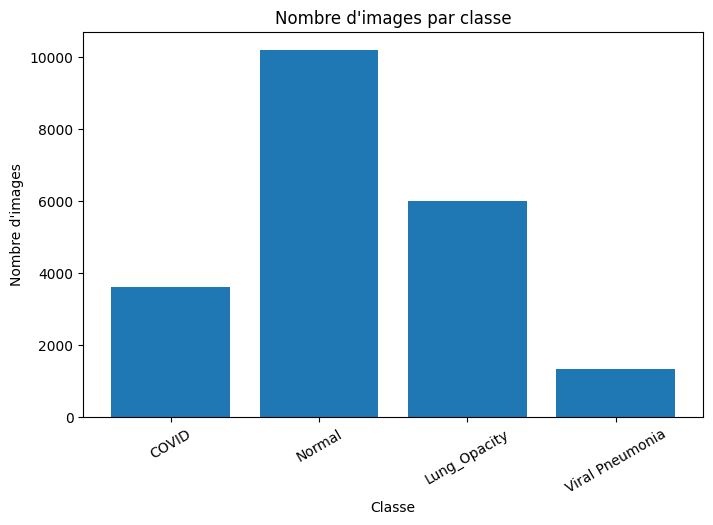

In [5]:
# Graphique de répartition des classes

plt.figure(figsize=(8, 5))
plt.bar(df_summary["classe"], df_summary["nombre_images"])
plt.title("Nombre d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=30)
plt.show()

In [6]:
# Vérification cohérence images et masks

check_results = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_names = {f.name for f in images_dir.glob("*.png")}
    mask_names = {f.name for f in masks_dir.glob("*.png")}
    
    missing_masks = image_names - mask_names
    missing_images = mask_names - image_names
    
    check_results.append({
        "classe": class_name,
        "images_sans_mask": len(missing_masks),
        "masks_sans_image": len(missing_images)
    })

df_check = pd.DataFrame(check_results)
df_check

,classe,images_sans_mask,masks_sans_image
0,COVID,0,0
1,Normal,0,0
2,Lung_Opacity,0,0
3,Viral Pneumonia,0,0


## 4. Caractéristiques des images

In [6]:
# Tableau image par image

image_infos = []

for class_name in classes:
    images_dir = data_path / class_name / "images"
    
    for img_path in images_dir.glob("*.png"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            image_infos.append({
                "classe": class_name,
                "fichier": img_path.name,
                "erreur_lecture": True
            })
            continue
        
        height, width = img.shape
        
        image_infos.append({
            "classe": class_name,
            "fichier": img_path.name,
            "largeur": width,
            "hauteur": height,
            "nb_pixels": width * height,
            "pixel_min": img.min(),
            "pixel_max": img.max(),
            "pixel_mean": img.mean(),
            "pixel_std": img.std(),
            "dtype": img.dtype,
            "erreur_lecture": False
        })

df_images = pd.DataFrame(image_infos)
df_images.head()

,classe,fichier,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std,dtype,erreur_lecture
0,COVID,COVID-1.png,299,299,89401,0,255,145.896847,51.816632,uint8,False
1,COVID,COVID-10.png,299,299,89401,0,227,141.355466,40.623291,uint8,False
2,COVID,COVID-100.png,299,299,89401,0,255,152.878570,73.778044,uint8,False
3,COVID,COVID-1000.png,299,299,89401,0,252,162.771054,76.249129,uint8,False
4,COVID,COVID-1001.png,299,299,89401,0,242,129.890784,66.179559,uint8,False


In [9]:
df_images.shape

(21165, 11)

In [10]:
df_images.describe()

,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std
count,21165.0,21165.0,21165.0,21165.000000,21165.000000,21165.000000,21165.000000
mean,299.0,299.0,89401.0,0.882920,243.812237,129.908506,59.017312
std,0.0,0.0,0.0,5.537436,15.987435,23.491756,11.104801
min,299.0,299.0,89401.0,0.000000,77.000000,25.511381,14.145251
25%,299.0,299.0,89401.0,0.000000,241.000000,113.313184,51.657089
50%,299.0,299.0,89401.0,0.000000,250.000000,127.133891,60.104209
75%,299.0,299.0,89401.0,0.000000,255.000000,146.682901,67.152950
max,299.0,299.0,89401.0,113.000000,255.000000,229.141676,106.998675


In [11]:
df_images.groupby("classe")[[
    "largeur", 
    "hauteur", 
    "nb_pixels", 
    "pixel_min", 
    "pixel_max", 
    "pixel_mean", 
    "pixel_std"
]].agg(["min", "max", "mean"])

largeur             hauteur             nb_pixels         \
                    min  max   mean     min  max   mean       min    max   
classe                                                                     
COVID               299  299  299.0     299  299  299.0     89401  89401   
Lung_Opacity        299  299  299.0     299  299  299.0     89401  89401   
Normal              299  299  299.0     299  299  299.0     89401  89401   
Viral Pneumonia     299  299  299.0     299  299  299.0     89401  89401   

                         pixel_min  ...           pixel_max                   \
                    mean       min  ...      mean       min  max        mean   
classe                              ...                                        
COVID            89401.0         0  ...  3.697179        77  255  240.156527   
Lung_Opacity     89401.0         0  ...  0.261144       156  255  241.690120   
Normal           89401.0         0  ...  0.258732       146  255  247.108320   
Viral Pneumonia  89401.0         0  ...  0.826022       152  255  238.149442   

                pixel_mean                          pixel_std              \
                       min         max        mean        min         max   
classe                                                                      
COVID            25.511381  216.561839  139.521210  14.145251  106.998675   
Lung_Opacity     32.226899  229.141676  126.021596  26.788407   93.454276   
Normal           26.443597  201.849543  129.389800  19.176520   98.862049   
Viral Pneumonia  64.772698  193.691961  125.369630  24.163092   87.315388   

                            
                      mean  
classe                      
COVID            54.647365  
Lung_Opacity     57.397085  
Normal           61.559355  
Viral Pneumonia  58.745215  

[4 rows x 21 columns]

In [12]:
# Les images ont-elles toutes la même taille ?

df_images[["largeur","hauteur"]].drop_duplicates()

,largeur,hauteur
0,299,299


In [13]:
# Y-a-t-il des images corrompues ?

df_images["erreur_lecture"].value_counts()

erreur_lecture
False    21165
Name: count, dtype: int64

In [14]:
# Les images sont-elles homogènes ?

df_images.groupby("classe")["pixel_mean"].describe()

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
COVID,3616.0,139.521210,25.029784,25.511381,126.883094,142.594753,155.970733,216.561839
Lung_Opacity,6012.0,126.021596,23.570601,32.226899,110.578643,120.819543,142.098830,229.141676
Normal,10192.0,129.389800,22.448670,26.443597,113.520593,125.509709,143.643505,201.849543
Viral Pneumonia,1345.0,125.369630,18.980974,64.772698,113.497880,126.860013,137.787776,193.691961


### 4.1 Intensité moyenne des pixels

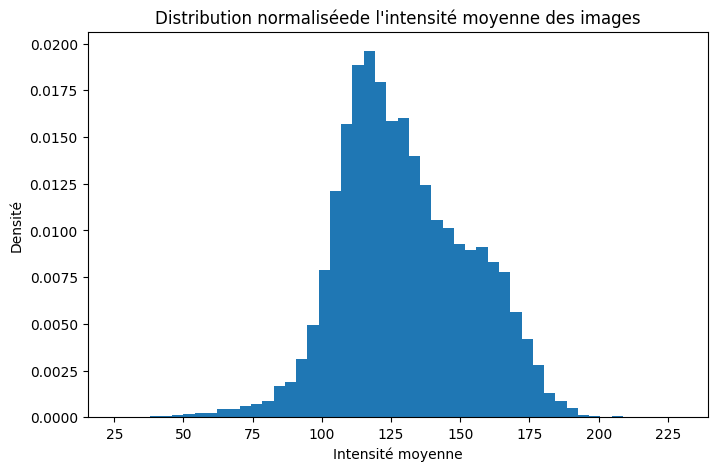

In [15]:
# Distribution des intensités moyennes des pixels

plt.figure(figsize=(8, 5))
plt.hist(df_images["pixel_mean"], bins=50, density=True,)
plt.title("Distribution normaliséede l'intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")
plt.show()

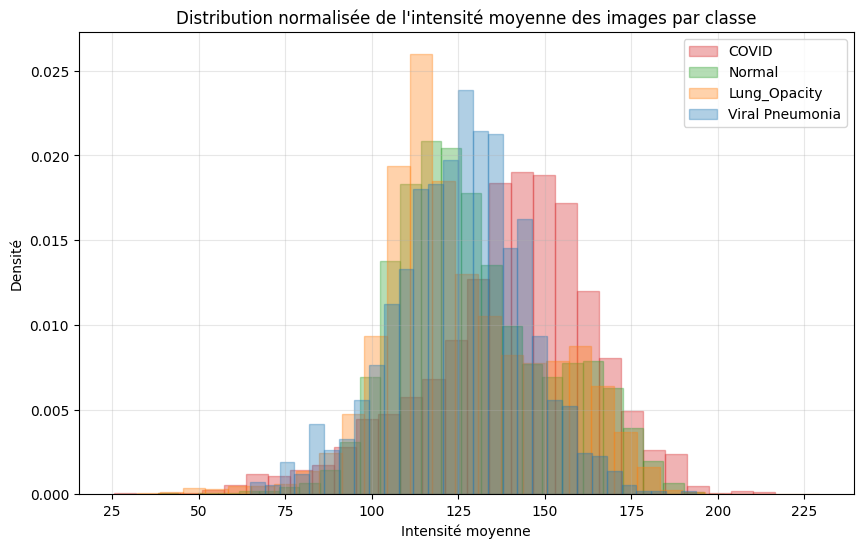

In [16]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_images[df_images["classe"] == class_name]
    
    plt.hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée de l'intensité moyenne des images par classe")
plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_22368\2420514113.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


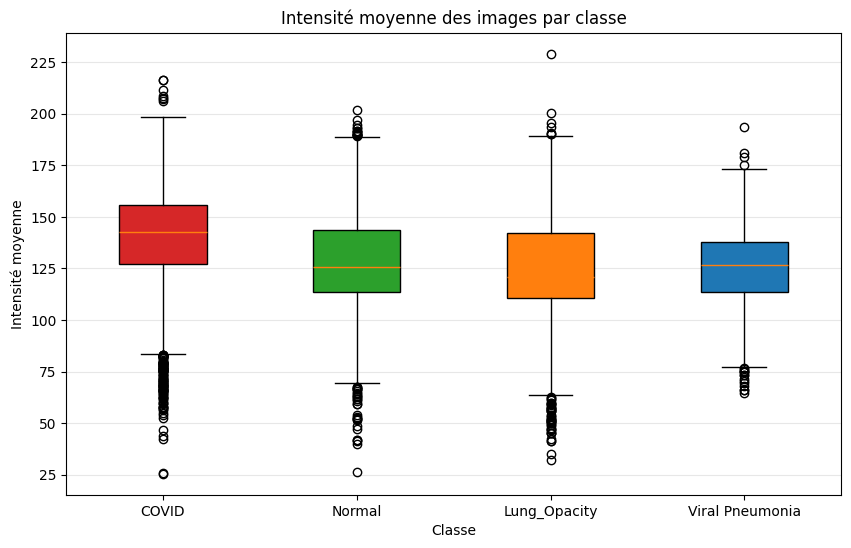

In [17]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_images[df_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Intensité moyenne des images par classe")
plt.xlabel("Classe")
plt.ylabel("Intensité moyenne")
plt.grid(axis="y", alpha=0.3)

plt.show()

Ce boxplot montre de nombreux outliers, des distributions asymétriques, et des variances visiblement différentes selon les classes. Il convient de réaliser un test de comparaison des moyennes entre les 4 classes. Au regard des tendances observées et de la non normalité des données, une ANOVA n'est pas réalisable. Je un test de Kruskal-Wallis est plus approprié.

In [7]:
# Confirmation des tendances par test Kruskal-Wallis

# H0 : Les distributions de pixel_mean sont identiques dans les 4 classes.
# H : Les distributions de pixel_mean ne sont pas identiques dans les 4 classes.

covid = df_images.query("classe=='COVID'")["pixel_mean"]
normal = df_images.query("classe=='Normal'")["pixel_mean"]
lung = df_images.query("classe=='Lung_Opacity'")["pixel_mean"]
viral = df_images.query("classe=='Viral Pneumonia'")["pixel_mean"]

H, p = kruskal(
    covid,
    normal,
    lung,
    viral
)

print("H =", H)
print("p =", p)

H = 987.3884656630119
p = 9.793596240350759e-214


La statistique H de Kruskal-Wallis mesure à quel point les distributions des groupes sont différentes. Ici elle est très élevée. Celà signifie que les ordres de grandeur des observations diffèrent fortement entre les groupes.

La p-value est ici fortement inférieure à 0.05. On rejette donc H0 avec un risque alpha=5% de se tromper. L'intensité moyenne des images n'est pas identique entre les quatre classes étudiées. Au moins une classe diffère des autres. Pour savoir lesquelles diffèrent, il faut faire le test post-hoc de Dunn.

In [10]:
# Test de Dunn :
# H0 : les distributions de pixel_mean sont identiques
# H1 : les distributions de pixel_mean sont différentes

dunn_results = sp.posthoc_dunn(
    df_images,
    val_col="pixel_mean",
    group_col="classe",
    p_adjust="bonferroni"
)

dunn_results

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,3.867179e-200,5.082645e-141,1.172754e-77
Lung_Opacity,3.867179e-200,1.000000e+00,1.921587e-18,1.000000e+00
Normal,5.082645e-141,1.921587e-18,1.000000e+00,1.166638e-03
Viral Pneumonia,1.172754e-77,1.000000e+00,1.166638e-03,1.000000e+00


Pour chaque p-value < 0.05 on rejette H0 avec un risque alpha = 5% de se tromper.

Avec des p-values fortement inférieures à 0.05 à chaque comparaison, seule la classe COVID est clairement différente des 3 autres classes.

Lung_Opacity et Viral Pneumonia sont indiscernables : fusionner ces 2 classes ?

La classe Normale aussi a des p-values inférieures à 0.05 à chaque comparaison, mais moins fortes que celles de la classe COVID, notamment avec Viral Pneumonia

Au regard de la quantité des données, il existe un risque d'amplification statistique de faibles différences. Il est donc judicieux de procéder une mesure de taille d'effet.

In [8]:
N = len(df_images)

eta2 = (H - len(classes) + 1) / (N - len(classes))
print(eta2)

0.04651899558919767


L'eta2 mesure la taille de l'effet, c'est-à-dire la proportion de la variabilité de la variable étudiée. Ici 4,65 % de la variabilité de l'intensité moyenne des images est expliquée par la classification, ce qui est assez faible. Celà peut s'expliquer par le fort chevauchement des données.

En croisant les différentes approches statistiques et les analyses graphiques, il apparait que l'intensité moyenne des pixelx contient une information discriminante vis-à-vis de la classe COVID, mais sont effet discriminant est atténué par la forte dispersion des données. Il faudrait envisager d'autres variables à exploiter, ainsi qu'une réduction de cette dispersion notamment par suppression des outliers.

In [18]:
# Sélection d'un échantillon d'images

import random
from pathlib import Path

random.seed(42)

selected_images = {}

for class_name in classes:
    images_dir = data_path / class_name / "images"
    image_files = sorted(list(images_dir.glob("*.png")))
    
    selected_images[class_name] = random.sample(image_files, 10)

for class_name, image_paths in selected_images.items():
    print(f"\n{class_name}")
    for img_path in image_paths:
        print(img_path.name)


COVID
COVID-3356.png
COVID-1409.png
COVID-1090.png
COVID-478.png
COVID-2011.png
COVID-1901.png
COVID-1821.png
COVID-1512.png
COVID-459.png
COVID-1376.png

Normal
Normal-8868.png
Normal-2106.png
Normal-9532.png
Normal-7046.png
Normal-1293.png
Normal-1264.png
Normal-2206.png
Normal-4049.png
Normal-4255.png
Normal-8277.png

Lung_Opacity
Lung_Opacity-5437.png
Lung_Opacity-1194.png
Lung_Opacity-5136.png
Lung_Opacity-2464.png
Lung_Opacity-867.png
Lung_Opacity-5790.png
Lung_Opacity-759.png
Lung_Opacity-5016.png
Lung_Opacity-4091.png
Lung_Opacity-2623.png

Viral Pneumonia
Viral Pneumonia-615.png
Viral Pneumonia-874.png
Viral Pneumonia-30.png
Viral Pneumonia-101.png
Viral Pneumonia-1292.png
Viral Pneumonia-567.png
Viral Pneumonia-414.png
Viral Pneumonia-1285.png
Viral Pneumonia-184.png
Viral Pneumonia-408.png


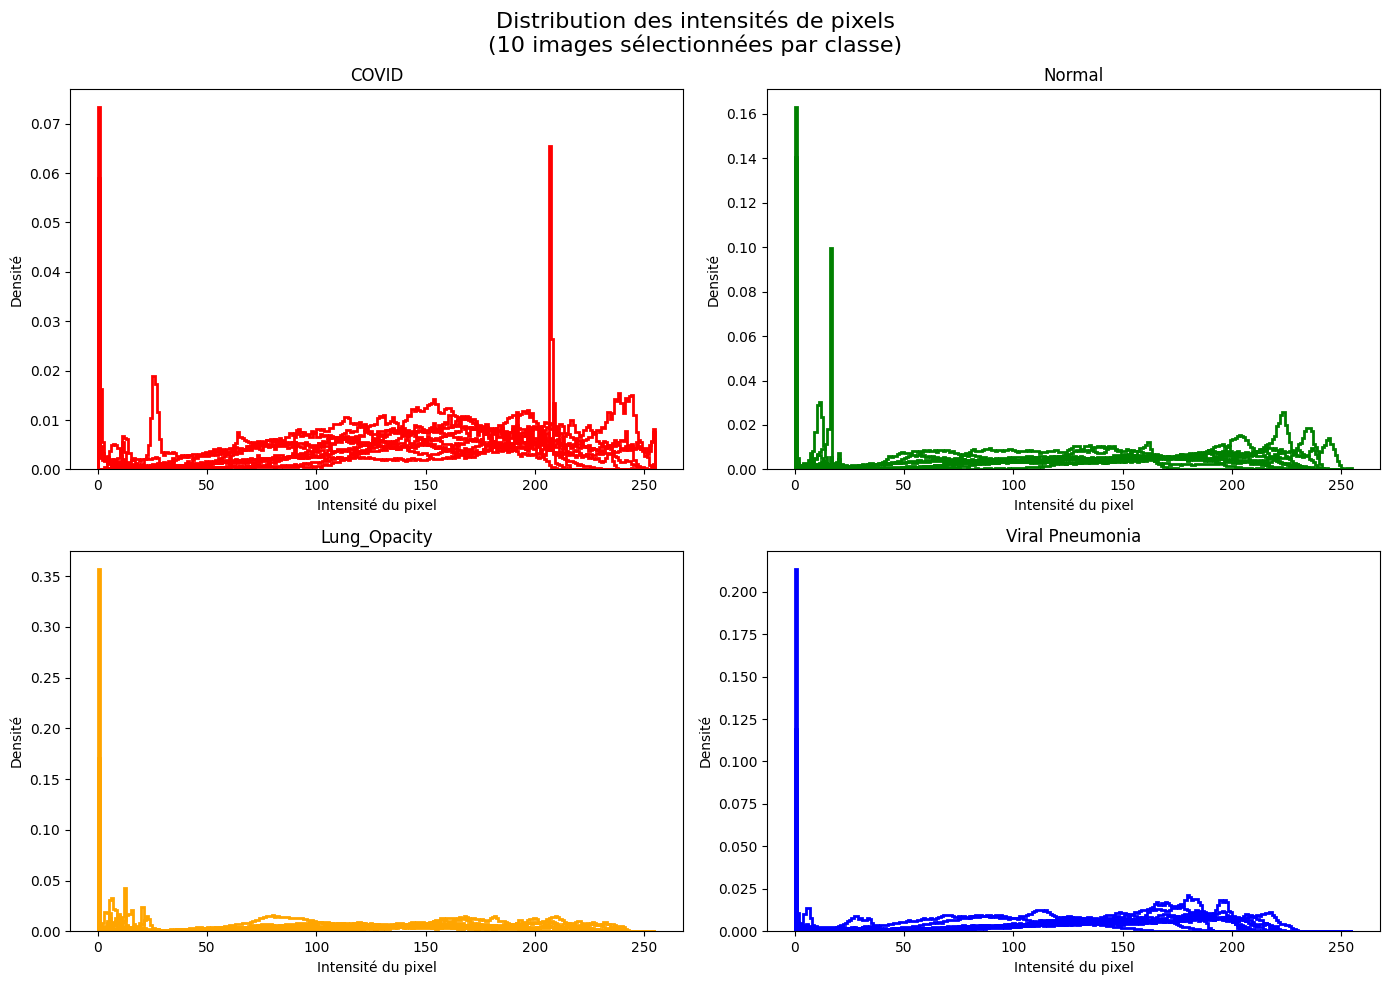

In [19]:
# Distribution des intensités de chaque pixel sur un échantillon d'images

colors = {
    "COVID": "red",
    "Normal": "green",
    "Lung_Opacity": "orange",
    "Viral Pneumonia": "blue"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, class_name in enumerate(classes):
    
    for i, img_path in enumerate(selected_images[class_name]):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        axes[idx].hist(
            img.ravel(),
            bins=256,
            range=(0, 255),
            density=True,
            histtype="step",
            linewidth=2,
            color=colors[class_name],
            label=f"Image {i+1}"
        )
    
    axes[idx].set_title(class_name)
    axes[idx].set_xlabel("Intensité du pixel")
    axes[idx].set_ylabel("Densité")

plt.suptitle(
    "Distribution des intensités de pixels\n"
    "(10 images sélectionnées par classe)",
    fontsize=16
)

plt.tight_layout()
plt.show()

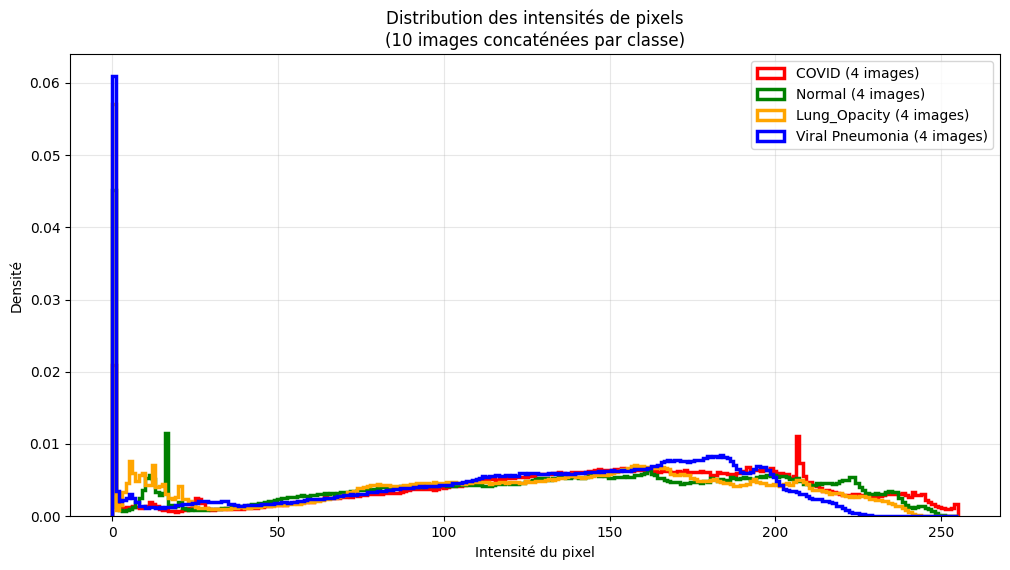

In [20]:
# Distribution des intensités de chaque pixel sur un échantillon d'images (concaténation des images par classe)

colors = {
    "COVID": "red",
    "Normal": "green",
    "Lung_Opacity": "orange",
    "Viral Pneumonia": "blue"
}

plt.figure(figsize=(12, 6))

for class_name in classes:

    pixels = []

    for img_path in selected_images[class_name]:

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        pixels.extend(img.ravel())

    pixels = np.array(pixels)

    plt.hist(
        pixels,
        bins=256,
        range=(0, 255),
        density=True,
        histtype="step",
        linewidth=2.5,
        color=colors[class_name],
        label=f"{class_name} (4 images)"
    )

plt.title(
    "Distribution des intensités de pixels\n"
    "(10 images concaténées par classe)"
)

plt.xlabel("Intensité du pixel")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4. Ecartg type de l'intensité des pixels

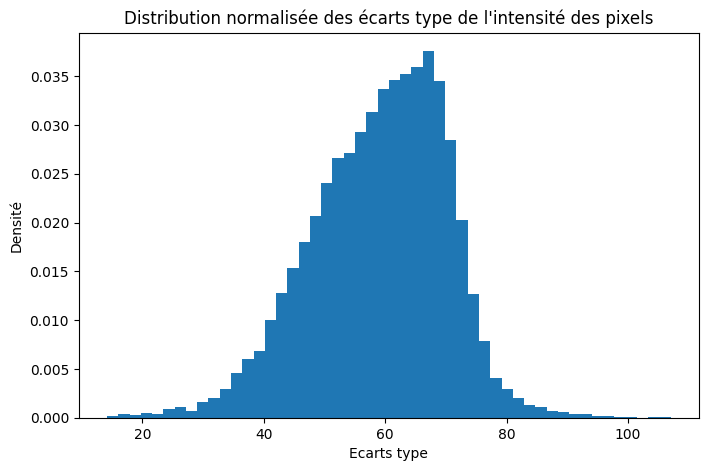

In [12]:
# Distribution des écart types des pixels

plt.figure(figsize=(8, 5))
plt.hist(df_images["pixel_std"], bins=50, density=True,)
plt.title("Distribution normalisée des écarts type de l'intensité des pixels")
plt.xlabel("Ecarts type")
plt.ylabel("Densité")
plt.show()

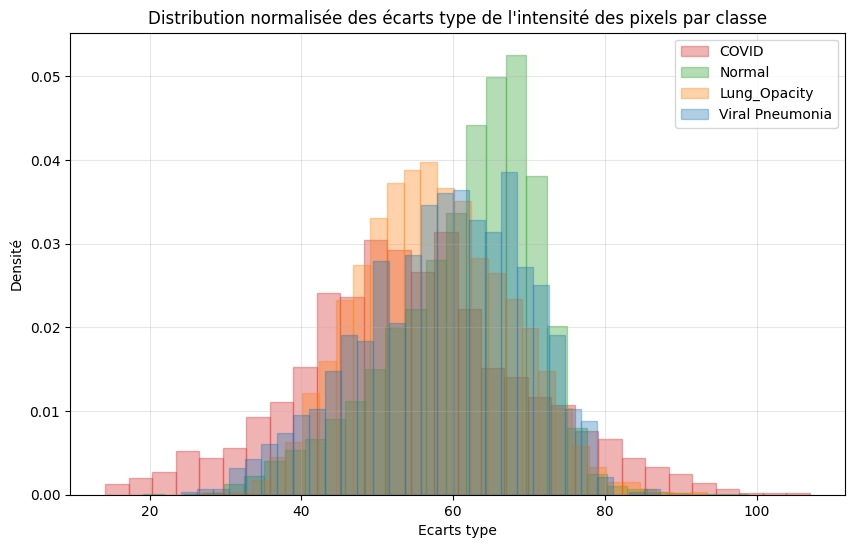

In [13]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_images[df_images["classe"] == class_name]
    
    plt.hist(
        subset["pixel_std"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée des écarts type de l'intensité des pixels par classe")
plt.xlabel("Ecarts type")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_25372\1953784469.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


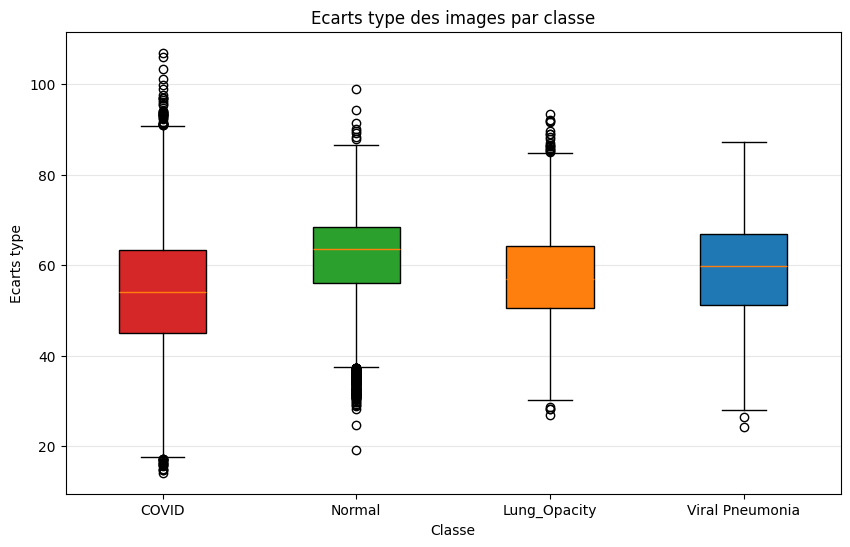

In [14]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_images[df_images["classe"] == class_name]["pixel_std"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Ecarts type des images par classe")
plt.xlabel("Classe")
plt.ylabel("Ecarts type")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [15]:
# Confirmation des tendances par test Kruskal-Wallis

# H0 : Les distributions de pixel_std sont identiques dans les 4 classes.
# H : Les distributions de pixel_std ne sont pas identiques dans les 4 classes.

covid = df_images.query("classe=='COVID'")["pixel_std"]
normal = df_images.query("classe=='Normal'")["pixel_std"]
lung = df_images.query("classe=='Lung_Opacity'")["pixel_std"]
viral = df_images.query("classe=='Viral Pneumonia'")["pixel_std"]

H, p = kruskal(
    covid,
    normal,
    lung,
    viral
)

print("H =", H)
print("p =", p)

H = 1393.781548622156
p = 6.584622839418785e-302


On confirme les résultats obtenus pour pixel_mean

In [17]:
# Test de Dunn :
# H0 : les distributions de pixel_std sont identiques
# H1 : les distributions de pixel_std sont différentes

dunn_results = sp.posthoc_dunn(
    df_images,
    val_col="pixel_std",
    group_col="classe",
    p_adjust="bonferroni"
)

dunn_results

,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,1.000000e+00,3.882383e-15,3.002196e-227,9.572513e-27
Lung_Opacity,3.882383e-15,1.000000e+00,9.957957e-171,2.575238e-08
Normal,3.002196e-227,9.957957e-171,1.000000e+00,8.321681e-21
Viral Pneumonia,9.572513e-27,2.575238e-08,8.321681e-21,1.000000e+00


Contrairement à la l'intensité moyenne, l'écartype permet de différencier Lung_Opacity et Viral Pneumonia.Différence plus accentuée entre Normal et Viral Pneumonia. Même tendance pour le reste.

## 5. Analyse des masks

In [21]:
mask_infos = []

for class_name in classes:
    masks_dir = data_path / class_name / "masks"
    
    for mask_path in masks_dir.glob("*.png"):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            mask_infos.append({
                "classe": class_name,
                "fichier": mask_path.name,
                "erreur_lecture": True
            })
            continue
        
        height, width = mask.shape
        mask_area = np.sum(mask > 0)
        total_area = width * height
        mask_ratio = mask_area / total_area
        
        mask_infos.append({
            "classe": class_name,
            "fichier": mask_path.name,
            "largeur": width,
            "hauteur": height,
            "surface_mask": mask_area,
            "surface_totale": total_area,
            "proportion_mask": mask_ratio,
            "pixel_min": mask.min(),
            "pixel_max": mask.max(),
            "erreur_lecture": False
        })

df_masks = pd.DataFrame(mask_infos)
df_masks.head()

,classe,fichier,largeur,hauteur,surface_mask,surface_totale,proportion_mask,pixel_min,pixel_max,erreur_lecture
0,COVID,COVID-1.png,256,256,15359,65536,0.234360,0,255,False
1,COVID,COVID-10.png,256,256,17225,65536,0.262833,0,255,False
2,COVID,COVID-100.png,256,256,15102,65536,0.230438,0,255,False
3,COVID,COVID-1000.png,256,256,16121,65536,0.245987,0,255,False
4,COVID,COVID-1001.png,256,256,9726,65536,0.148407,0,255,False


In [22]:
df_masks.shape

(21165, 10)

In [23]:
df_masks.describe()

,largeur,hauteur,surface_mask,surface_totale,proportion_mask,pixel_min,pixel_max
count,21165.0,21165.0,21165.000000,21165.0,21165.000000,21165.0,21165.0
mean,256.0,256.0,15673.297330,65536.0,0.239156,0.0,255.0
std,0.0,0.0,4061.552087,0.0,0.061974,0.0,0.0
min,256.0,256.0,1901.000000,65536.0,0.029007,0.0,255.0
25%,256.0,256.0,12850.000000,65536.0,0.196075,0.0,255.0
50%,256.0,256.0,15426.000000,65536.0,0.235382,0.0,255.0
75%,256.0,256.0,18204.000000,65536.0,0.277771,0.0,255.0
max,256.0,256.0,38028.000000,65536.0,0.580261,0.0,255.0


In [24]:
df_masks.groupby("classe")[["surface_mask", "proportion_mask"]].agg(["min", "max", "mean", "std"])

surface_mask                                    \
                         min    max          mean          std   
classe                                                           
COVID                   2501  38028  16041.876659  4813.899286   
Lung_Opacity            1901  29445  14116.761643  3624.360363   
Normal                  2186  30098  16512.747547  3821.825916   
Viral Pneumonia         6666  30437  15278.823792  3350.858413   

                proportion_mask                                
                            min       max      mean       std  
classe                                                         
COVID                  0.038162  0.580261  0.244780  0.073454  
Lung_Opacity           0.029007  0.449295  0.215405  0.055303  
Normal                 0.033356  0.459259  0.251965  0.058316  
Viral Pneumonia        0.101715  0.464432  0.233136  0.051130

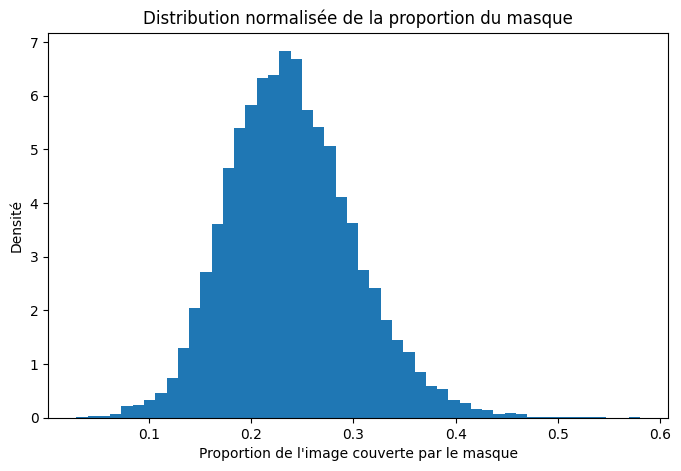

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df_masks["proportion_mask"], bins=50, density=True)
plt.title("Distribution normalisée de la proportion du masque")
plt.xlabel("Proportion de l'image couverte par le masque")
plt.ylabel("Densité")
plt.show()

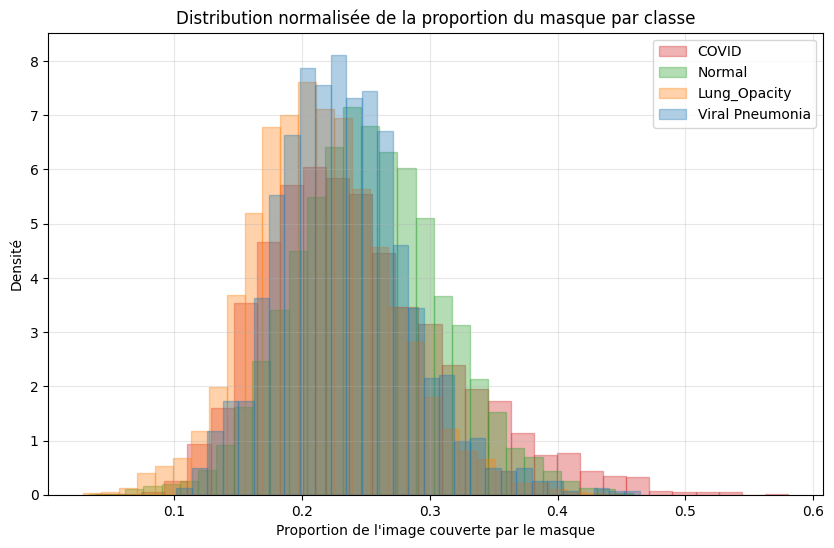

In [26]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",          
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4"  
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_masks[df_masks["classe"] == class_name]
    
    plt.hist(
        subset["proportion_mask"],
        bins=30,
        density=True,
        alpha=0.35,                    
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title("Distribution normalisée de la proportion du masque par classe")
plt.xlabel("Proportion de l'image couverte par le masque")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

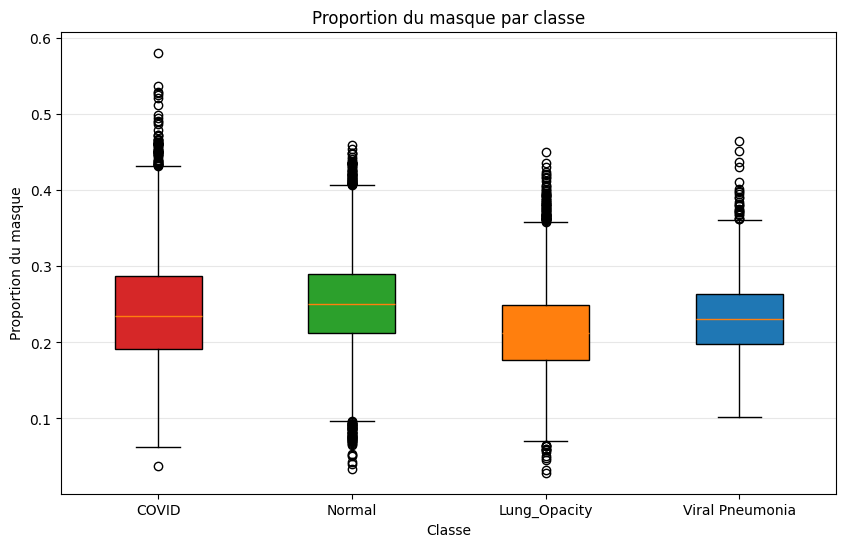

In [27]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

data_to_plot = [
    df_masks[df_masks["classe"] == class_name]["proportion_mask"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    tick_labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Proportion du masque par classe")
plt.xlabel("Classe")
plt.ylabel("Proportion du masque")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Visualisations

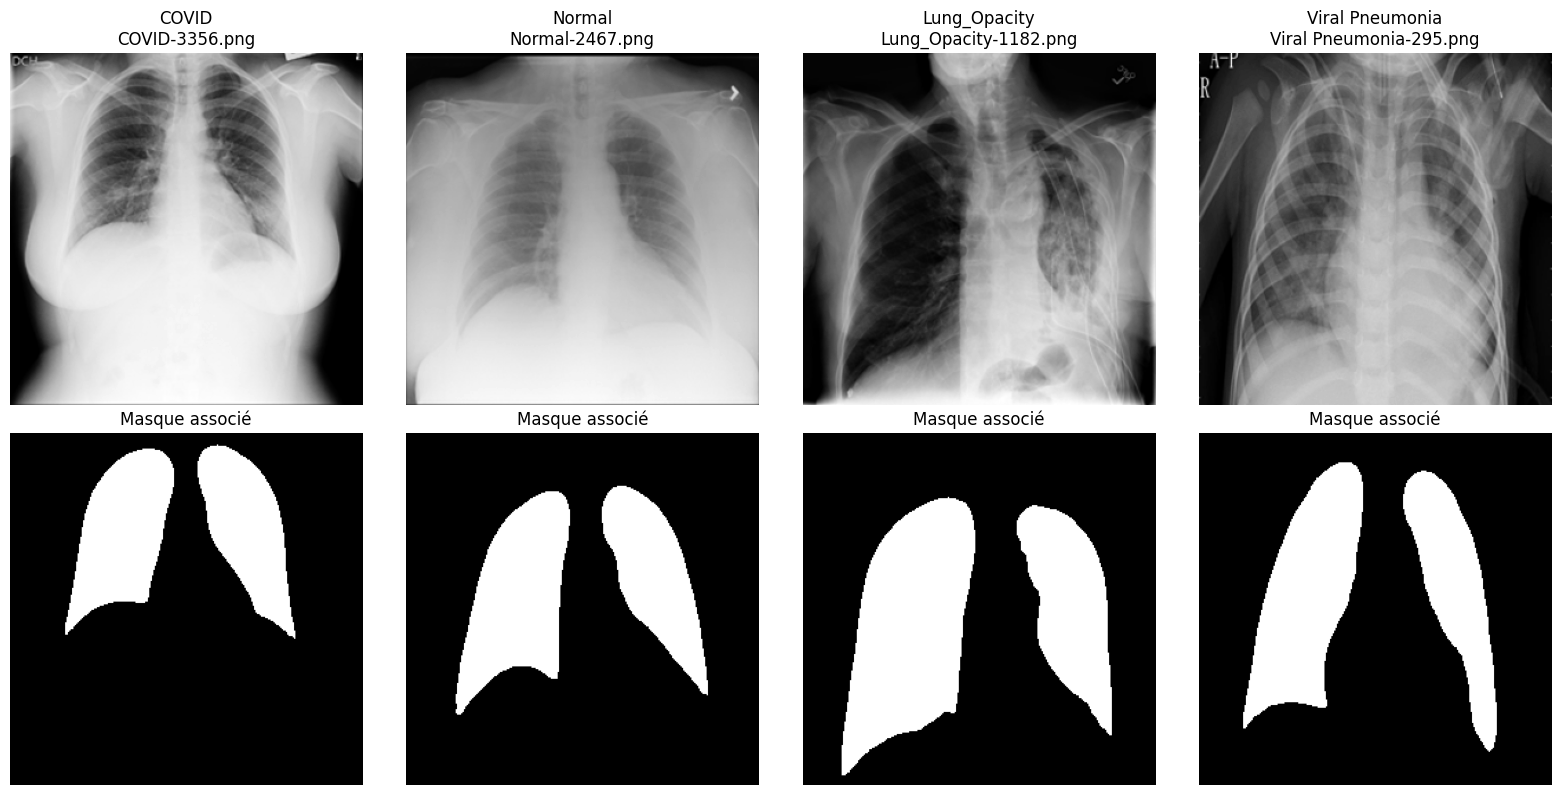

In [28]:
# Images brutes et masks associés

random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, class_name in enumerate(classes):
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    image_files = list(images_dir.glob("*.png"))
    img_path = random.choice(image_files)
    mask_path = masks_dir / img_path.name
    
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    axes[0, idx].imshow(img, cmap="gray")
    axes[0, idx].set_title(f"{class_name}\n{img_path.name}")
    axes[0, idx].axis("off")
    
    axes[1, idx].imshow(mask, cmap="gray")
    axes[1, idx].set_title("Masque associé")
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()

## Application des masks après redimensionnement

COVID
Image : COVID-3356.png (299, 299)
Masque : COVID-3356.png (256, 256)
Normal
Image : Normal-2467.png (299, 299)
Masque : Normal-2467.png (256, 256)
Lung_Opacity
Image : Lung_Opacity-1182.png (299, 299)
Masque : Lung_Opacity-1182.png (256, 256)
Viral Pneumonia
Image : Viral Pneumonia-295.png (299, 299)
Masque : Viral Pneumonia-295.png (256, 256)


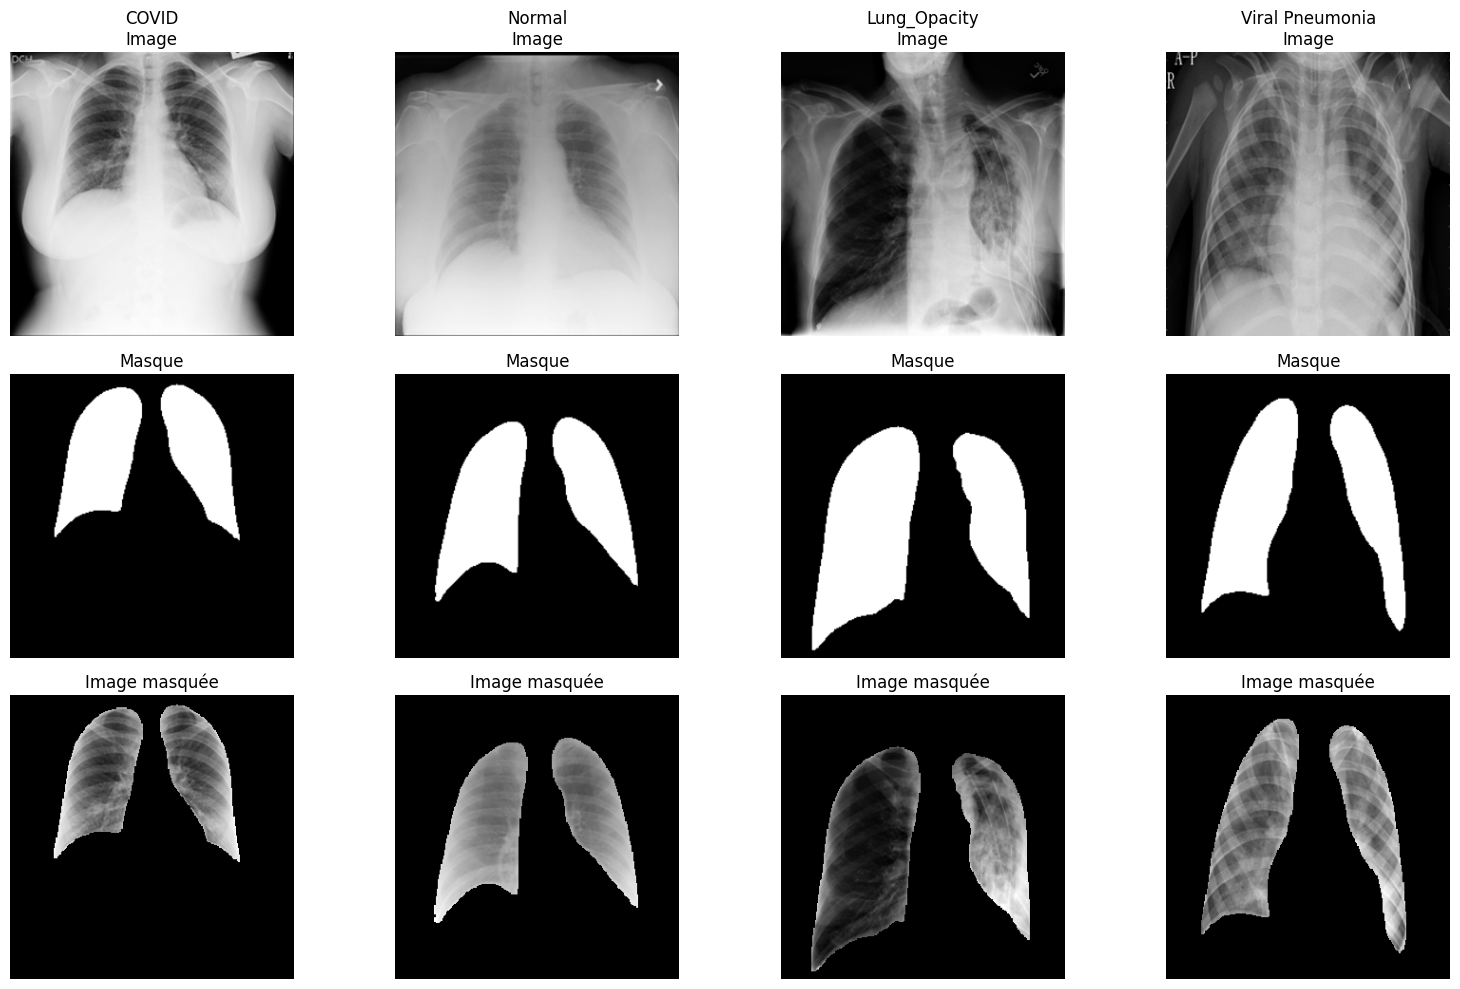

In [31]:
random.seed(42)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for idx, class_name in enumerate(classes):
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"

    img_path = random.choice(list(images_dir.glob("*.png")))
    mask_path = masks_dir / img_path.name

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Vérification
    print(class_name)
    print("Image :", img_path.name, img.shape)
    print("Masque :", mask_path.name, mask.shape)

    # Redimensionner le masque si nécessaire
    if img.shape != mask.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    # S'assurer que le masque est bien en uint8
    mask = mask.astype(np.uint8)

    masked_img = cv2.bitwise_and(img, img, mask=mask)

    axes[0, idx].imshow(img, cmap="gray")
    axes[0, idx].set_title(f"{class_name}\nImage")
    axes[0, idx].axis("off")

    axes[1, idx].imshow(mask, cmap="gray")
    axes[1, idx].set_title("Masque")
    axes[1, idx].axis("off")

    axes[2, idx].imshow(masked_img, cmap="gray")
    axes[2, idx].set_title("Image masquée")
    axes[2, idx].axis("off")

plt.tight_layout()
plt.show()

In [29]:
print("Classe :", class_name)
print("Image :", img_path.name, img.shape)

if mask is None:
    print("Masque non trouvé :", mask_path)
else:
    print("Masque :", mask_path.name, mask.shape)

Classe : Viral Pneumonia
Image : Viral Pneumonia-295.png (299, 299)
Masque : Viral Pneumonia-295.png (256, 256)


## 6. Bilan anomalies

In [30]:
print("Images non lisibles :", df_images["erreur_lecture"].sum())
print("Masques non lisibles :", df_masks["erreur_lecture"].sum())

print("Images avec pixel max = 0 :", (df_images["pixel_max"] == 0).sum())
print("Masques vides :", (df_masks["surface_mask"] == 0).sum())

Images non lisibles : 0
Masques non lisibles : 0
Images avec pixel max = 0 : 0
Masques vides : 0


## 7. Application généralisée des masks - Nouveau répertoire

In [ ]:
# Dossier source
data_path = Path("../../../COVID-19_Radiography_Dataset")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

# Dossier de sortie
output_path = Path("../../../COVID-19_Radiography_Dataset_processed")
output_path.mkdir(exist_ok=True)

for class_name in classes:
    
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    output_class_dir = output_path / class_name / "masked_images"
    output_class_dir.mkdir(parents=True, exist_ok=True)
    
    image_files = sorted(images_dir.glob("*.png"))
    
    for img_path in image_files:
        
        mask_path = masks_dir / img_path.name
        
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Image non lisible : {img_path}")
            continue
        
        if mask is None:
            print(f"Masque manquant ou non lisible : {mask_path}")
            continue
        
        # Redimensionnement du masque à la taille de l'image
        height, width = img.shape
        
        mask_resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST
        )
        
        # Binarisation du masque : pixels > 0 deviennent 255
        mask_binary = np.where(mask_resized > 0, 255, 0).astype(np.uint8)
        
        # Application du masque
        masked_img = cv2.bitwise_and(img, img, mask=mask_binary)
        
        # Sauvegarde
        output_file = output_class_dir / img_path.name
        cv2.imwrite(str(output_file), masked_img)

print("Traitement terminé.")
print("Images masquées enregistrées dans :", output_path.resolve())

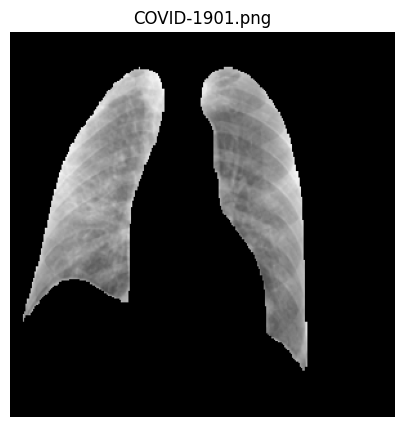

In [34]:
# Vérification

class_name = "COVID"

example_path = random.choice(
    list((Path("../../../COVID-19_Radiography_Dataset_processed") / class_name / "masked_images").glob("*.png"))
)

masked_img = cv2.imread(str(example_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(masked_img, cmap="gray")
plt.title(example_path.name)
plt.axis("off")
plt.show()

In [35]:
masked_dir = Path("../../../COVID-19_Radiography_Dataset_processed") / "COVID" / "masked_images"

print(masked_dir)
print(masked_dir.exists())

if masked_dir.exists():
    print(list(masked_dir.iterdir())[:10])

..\..\..\COVID-19_Radiography_Dataset_processed\COVID\masked_images
True
[WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-10.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-100.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1000.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1001.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1002.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1003.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1004.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1005.png'), WindowsPath('../../../COVID-19_Radiograph

## 8. Impact du mask

In [37]:
processed_path = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed"
)

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

masked_infos = []

for class_name in classes:
    
    images_dir = processed_path / class_name / "masked_images"
    
    for img_path in images_dir.glob("*.png"):
        
        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )
        
        if img is None:
            continue
        
        height, width = img.shape
        
        masked_infos.append({
            "classe": class_name,
            "fichier": img_path.name,
            "largeur": width,
            "hauteur": height,
            "nb_pixels": width * height,
            "pixel_min": img.min(),
            "pixel_max": img.max(),
            "pixel_mean": img.mean(),
            "pixel_std": img.std()
        })

df_masked_images = pd.DataFrame(masked_infos)

print(df_masked_images.shape)
df_masked_images.head()

(21165, 9)


,classe,fichier,largeur,hauteur,nb_pixels,pixel_min,pixel_max,pixel_mean,pixel_std
0,COVID,COVID-1.png,299,299,89401,0,186,29.659881,55.333928
1,COVID,COVID-10.png,299,299,89401,0,179,32.049328,55.005081
2,COVID,COVID-100.png,299,299,89401,0,233,27.707565,54.466222
3,COVID,COVID-1000.png,299,299,89401,0,236,33.070346,62.669766
4,COVID,COVID-1001.png,299,299,89401,0,198,18.744130,46.364107


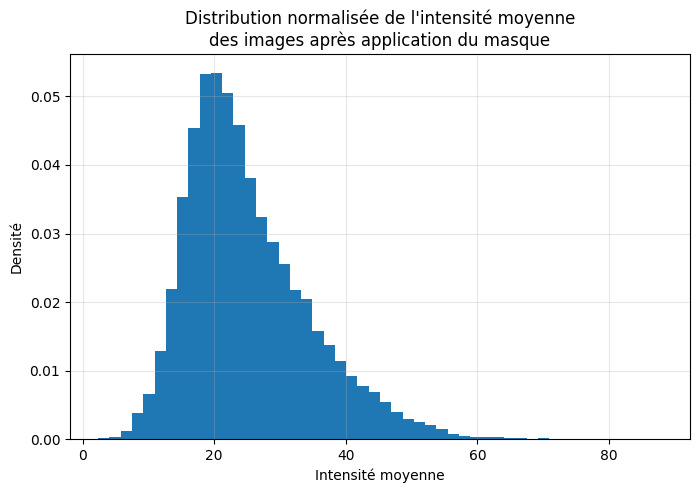

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_masked_images["pixel_mean"],
    bins=50,
    density=True
)

plt.title(
    "Distribution normalisée de l'intensité moyenne\n"
    "des images après application du masque"
)

plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")

plt.grid(alpha=0.3)

plt.show()

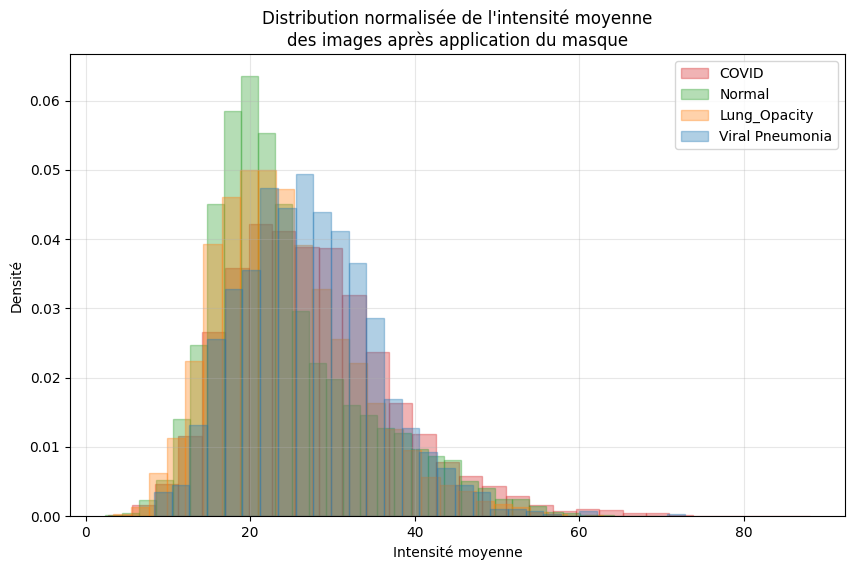

In [39]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

plt.figure(figsize=(10, 6))

for class_name in classes:
    
    subset = df_masked_images[
        df_masked_images["classe"] == class_name
    ]
    
    plt.hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

plt.title(
    "Distribution normalisée de l'intensité moyenne\n"
    "des images après application du masque"
)

plt.xlabel("Intensité moyenne")
plt.ylabel("Densité")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

C:\Users\n_a_e\AppData\Local\Temp\ipykernel_22368\3646666377.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


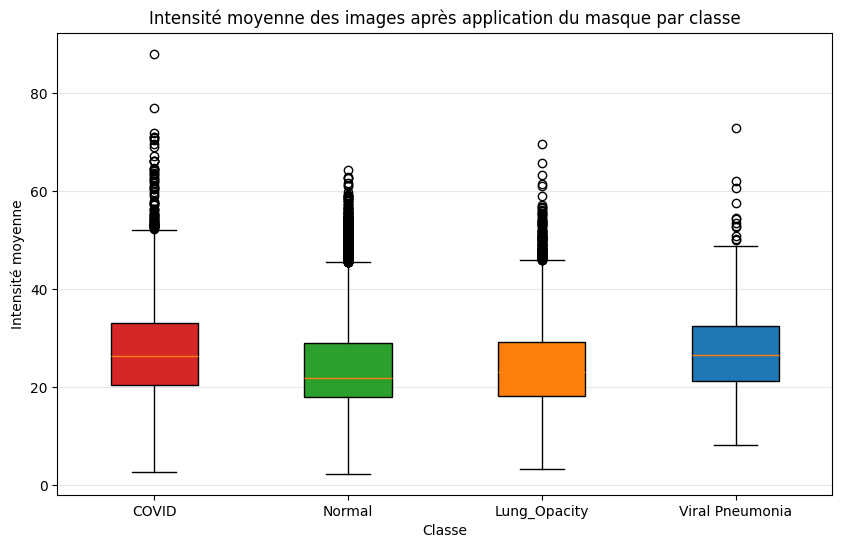

In [40]:
colors = {
    "COVID": "#d62728",           
    "Normal": "#2ca02c",        
    "Lung_Opacity": "#ff7f0e",    
    "Viral Pneumonia": "#1f77b4" 
}

data_to_plot = [
    df_masked_images[df_masked_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=classes
)

# Application des couleurs
for patch, class_name in zip(box['boxes'], classes):
    patch.set_facecolor(colors[class_name])

plt.title("Intensité moyenne des images après application du masque par classe")
plt.xlabel("Classe")
plt.ylabel("Intensité moyenne")
plt.grid(axis="y", alpha=0.3)

plt.show()

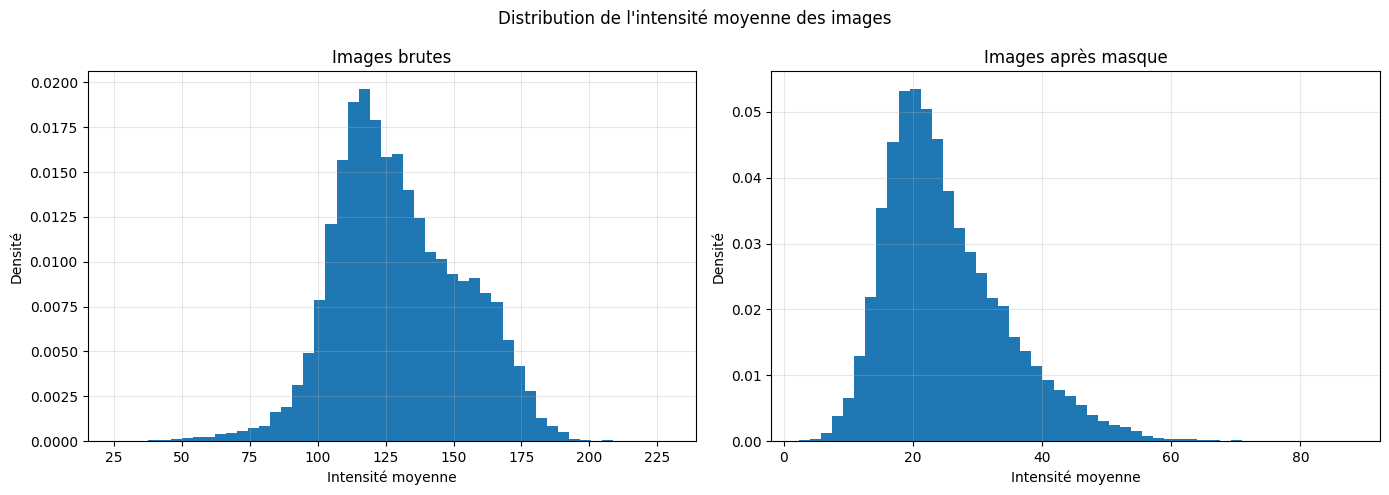

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Images brutes
axes[0].hist(
    df_images["pixel_mean"],
    bins=50,
    density=True
)

axes[0].set_title("Images brutes")
axes[0].set_xlabel("Intensité moyenne")
axes[0].set_ylabel("Densité")
axes[0].grid(alpha=0.3)

# Images masquées
axes[1].hist(
    df_masked_images["pixel_mean"],
    bins=50,
    density=True
)

axes[1].set_title("Images après masque")
axes[1].set_xlabel("Intensité moyenne")
axes[1].set_ylabel("Densité")
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Distribution de l'intensité moyenne des images"
)

plt.tight_layout()
plt.show()

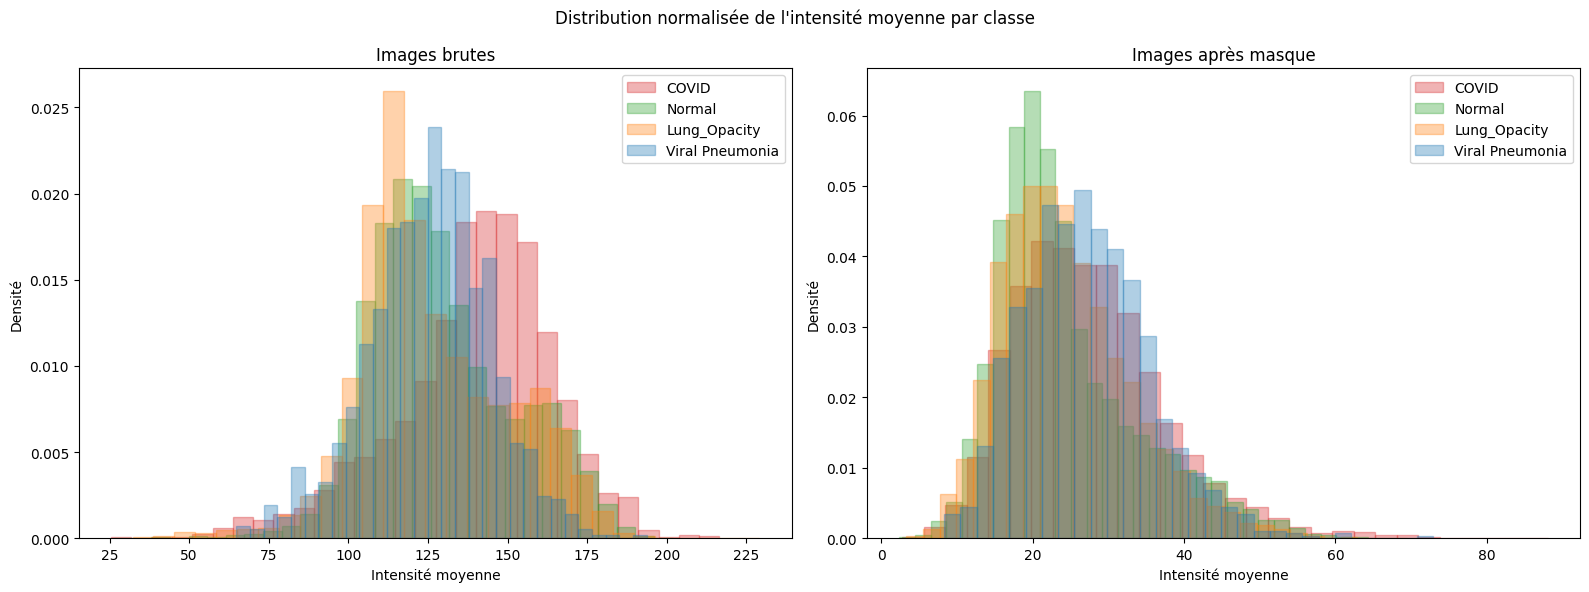

In [76]:
colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Images brutes
for class_name in classes:

    subset = df_images[
        df_images["classe"] == class_name
    ]

    axes[0].hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

axes[0].set_title("Images brutes")
axes[0].set_xlabel("Intensité moyenne")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Images masquées
for class_name in classes:

    subset = df_masked_images[
        df_masked_images["classe"] == class_name
    ]

    axes[1].hist(
        subset["pixel_mean"],
        bins=30,
        density=True,
        alpha=0.35,
        color=colors[class_name],
        edgecolor=colors[class_name],
        label=class_name
    )

axes[1].set_title("Images après masque")
axes[1].set_xlabel("Intensité moyenne")
axes[1].set_ylabel("Densité")
axes[1].legend()

plt.suptitle(
    "Distribution normalisée de l'intensité moyenne par classe"
)

plt.tight_layout()
plt.show()

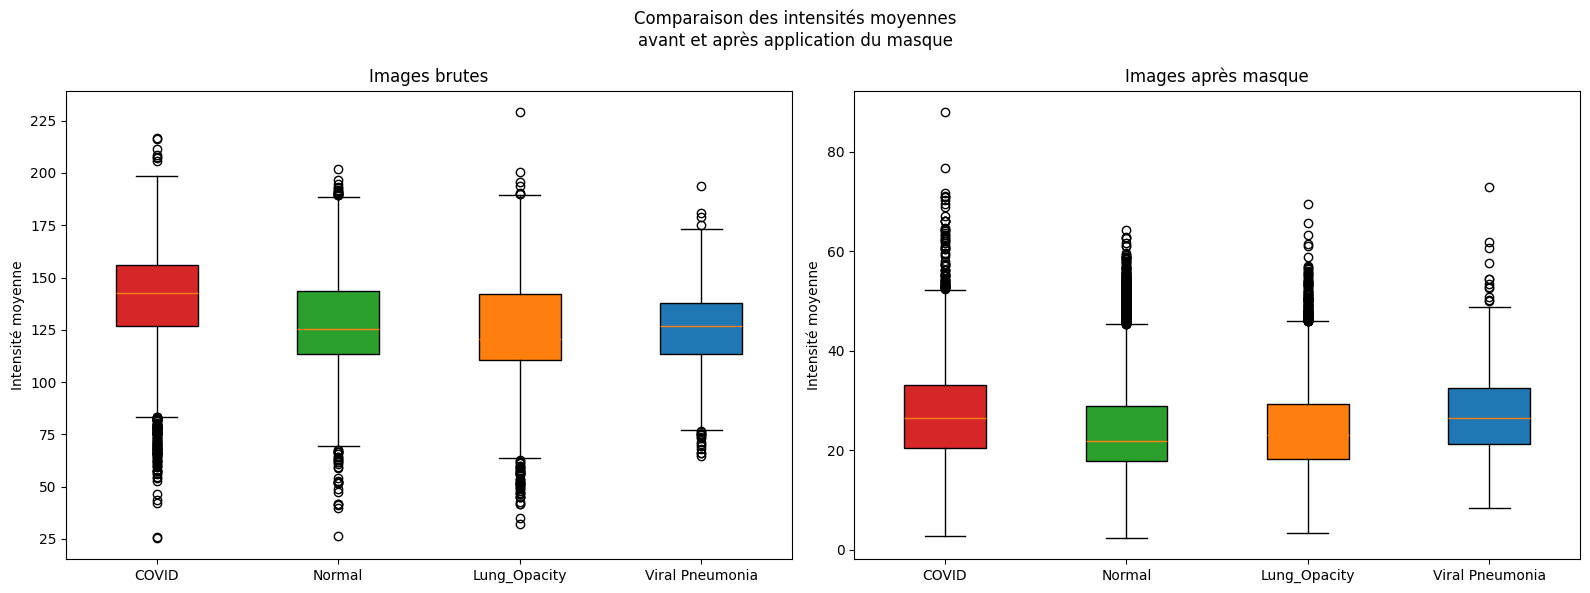

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Images brutes

data_raw = [
    df_images[df_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

box_raw = axes[0].boxplot(
    data_raw,
    patch_artist=True,
    tick_labels=classes
)

for patch, class_name in zip(box_raw["boxes"], classes):
    patch.set_facecolor(colors[class_name])

axes[0].set_title("Images brutes")
axes[0].set_ylabel("Intensité moyenne")

# Images masquées

data_masked = [
    df_masked_images[df_masked_images["classe"] == class_name]["pixel_mean"]
    for class_name in classes
]

box_masked = axes[1].boxplot(
    data_masked,
    patch_artist=True,
    tick_labels=classes
)

for patch, class_name in zip(box_masked["boxes"], classes):
    patch.set_facecolor(colors[class_name])

axes[1].set_title("Images après masque")
axes[1].set_ylabel("Intensité moyenne")

plt.suptitle(
    "Comparaison des intensités moyennes\navant et après application du masque"
)

plt.tight_layout()
plt.show()

## 9. ACP

In [57]:
# Préparation des images

Data_path = Path("../../../COVID-19_Radiography_Dataset")

classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

target_size = (128, 128)  # taille réduite pour ACP

In [42]:
# Préparation des matrices

def load_images_for_pca(data_path, classes, mode="raw", target_size=(64, 64)):
    """
    mode :
    - "raw"    : images brutes
    - "mask"   : masques seuls
    - "masked" : images après application du masque
    """
    
    X = []
    y = []
    filenames = []
    
    for class_name in classes:
        images_dir = data_path / class_name / "images"
        masks_dir = data_path / class_name / "masks"
        
        image_files = sorted(images_dir.glob("*.png"))
        
        for img_path in image_files:
            mask_path = masks_dir / img_path.name
            
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            if img is None or mask is None:
                continue
            
            if mode == "raw":
                img_to_use = img
            
            elif mode == "mask":
                img_to_use = mask
            
            elif mode == "masked":
                h, w = img.shape
                
                mask_resized = cv2.resize(
                    mask,
                    (w, h),
                    interpolation=cv2.INTER_NEAREST
                )
                
                mask_binary = np.where(mask_resized > 0, 255, 0).astype(np.uint8)
                img_to_use = cv2.bitwise_and(img, img, mask=mask_binary)
            
            else:
                raise ValueError("mode doit être 'raw', 'mask' ou 'masked'")
            
            img_resized = cv2.resize(
                img_to_use,
                target_size,
                interpolation=cv2.INTER_AREA
            )
            
            X.append(img_resized.ravel())
            y.append(class_name)
            filenames.append(img_path.name)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y, filenames

In [45]:
# Fonction ACP et graphiques

def run_pca_and_plot(X, y, title):
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "classe": y
    })
    
    plt.figure(figsize=(9, 7))
    
    for class_name in classes:
        subset = df_pca[df_pca["classe"] == class_name]
        
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=class_name,
            color=colors[class_name],
            alpha=0.3,   # transparence ici
            s=20
        )
    
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    print("Variance expliquée PC1 :", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
    print("Variance expliquée PC2 :", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
    print("Variance expliquée totale :", round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")
    
    return df_pca, pca

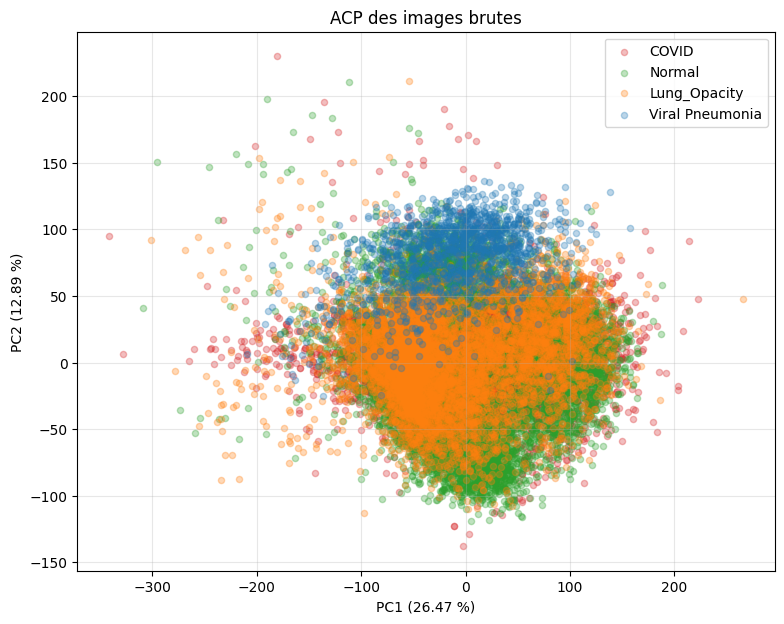

Variance expliquée PC1 : 26.47 %
Variance expliquée PC2 : 12.89 %
Variance expliquée totale : 39.36 %


In [54]:
# ACP images brutes

X_raw, y_raw, files_raw = load_images_for_pca(
    data_path,
    classes,
    mode="raw",
    target_size=target_size
)

df_pca_raw, pca_raw = run_pca_and_plot(
    X_raw,
    y_raw,
    "ACP des images brutes"
)

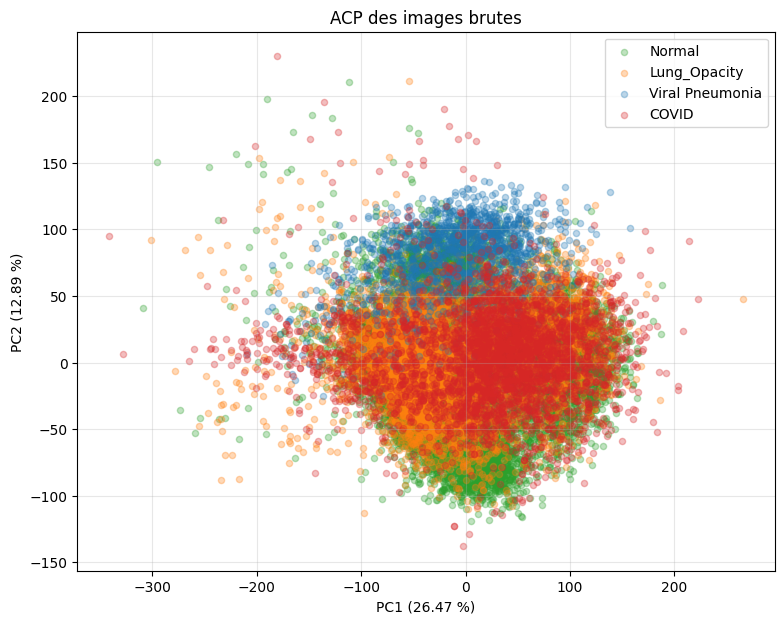

Variance expliquée PC1 : 26.47 %
Variance expliquée PC2 : 12.89 %
Variance expliquée totale : 39.36 %


In [59]:
# ACP images brutes avec les COVID en avant

X_raw, y_raw, files_raw = load_images_for_pca(
    data_path,
    classes,
    mode="raw",
    target_size=target_size
)

df_pca_raw, pca_raw = run_pca_and_plot(
    X_raw,
    y_raw,
    "ACP des images brutes"
)

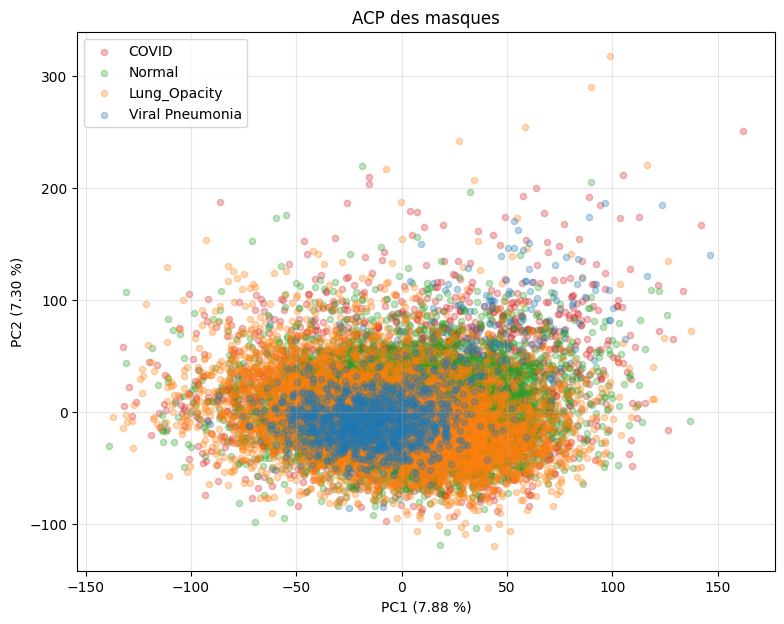

Variance expliquée PC1 : 7.88 %
Variance expliquée PC2 : 7.3 %
Variance expliquée totale : 15.17 %


In [55]:
# ACP Masks

X_masks, y_masks, files_masks = load_images_for_pca(
    data_path,
    classes,
    mode="mask",
    target_size=target_size
)

df_pca_masks, pca_masks = run_pca_and_plot(
    X_masks,
    y_masks,
    "ACP des masques"
)

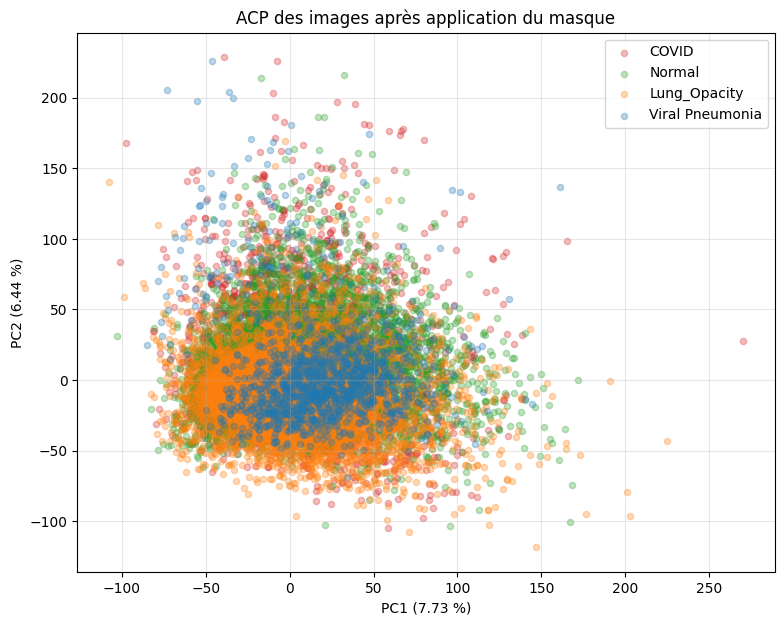

Variance expliquée PC1 : 7.73 %
Variance expliquée PC2 : 6.44 %
Variance expliquée totale : 14.17 %


In [56]:
# ACP images masquées

X_masked, y_masked, files_masked = load_images_for_pca(
    data_path,
    classes,
    mode="masked",
    target_size=target_size
)

df_pca_masked, pca_masked = run_pca_and_plot(
    X_masked,
    y_masked,
    "ACP des images après application du masque"
)

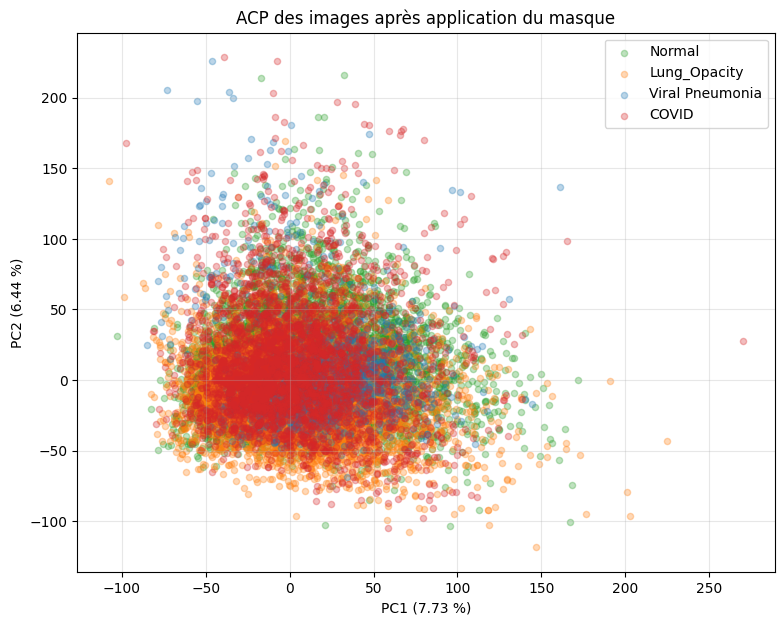

Variance expliquée PC1 : 7.73 %
Variance expliquée PC2 : 6.44 %
Variance expliquée totale : 14.17 %


In [58]:
# ACP images masquées avec les COVID en avant

X_masked, y_masked, files_masked = load_images_for_pca(
    data_path,
    classes,
    mode="masked",
    target_size=target_size
)

df_pca_masked, pca_masked = run_pca_and_plot(
    X_masked,
    y_masked,
    "ACP des images après application du masque"
)

## 10 Essai avec mask Open CV

In [49]:
data_path = Path("../../../COVID-19_Radiography_Dataset")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

auto_masks_path = Path("../../../COVID-19_Radiography_Dataset_auto_masks")
auto_masks_path.mkdir(exist_ok=True)

In [50]:
def create_lung_mask_from_xray(img):
    """
    Crée un masque approximatif du thorax/poumons à partir d'une radiographie.
    img doit être une image en niveaux de gris.
    """
    
    # Normalisation entre 0 et 255
    img_norm = cv2.normalize(
        img,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    ).astype(np.uint8)
    
    # Flou léger pour réduire le bruit
    blurred = cv2.GaussianBlur(img_norm, (5, 5), 0)
    
    # Seuillage d'Otsu
    _, thresh = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # Inversion possible selon le résultat
    # On garde le masque qui couvre une zone raisonnable de l'image
    ratio_white = np.sum(thresh > 0) / thresh.size
    
    if ratio_white > 0.6:
        thresh = cv2.bitwise_not(thresh)
    
    # Morphologie : fermeture puis ouverture
    kernel = np.ones((7, 7), np.uint8)
    
    mask = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )
    
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )
    
    # Garder les plus grandes composantes connexes
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )
    
    if num_labels <= 1:
        return mask
    
    # Trier les composantes par surface, sauf le fond
    components = []
    
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        components.append((label, area))
    
    components = sorted(
        components,
        key=lambda x: x[1],
        reverse=True
    )
    
    # Garder les 2 plus grandes composantes, souvent les deux poumons
    final_mask = np.zeros_like(mask)
    
    for label, area in components[:2]:
        final_mask[labels == label] = 255
    
    # Dernière fermeture pour lisser
    final_mask = cv2.morphologyEx(
        final_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )
    
    return final_mask

In [51]:
for class_name in classes:
    
    images_dir = data_path / class_name / "images"
    
    output_dir = auto_masks_path / class_name / "masks"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for img_path in sorted(images_dir.glob("*.png")):
        
        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )
        
        if img is None:
            print("Image non lisible :", img_path)
            continue
        
        auto_mask = create_lung_mask_from_xray(img)
        
        output_file = output_dir / img_path.name
        cv2.imwrite(str(output_file), auto_mask)

print("Création des masques automatiques terminée.")
print(auto_masks_path.resolve())

Création des masques automatiques terminée.
C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_auto_masks


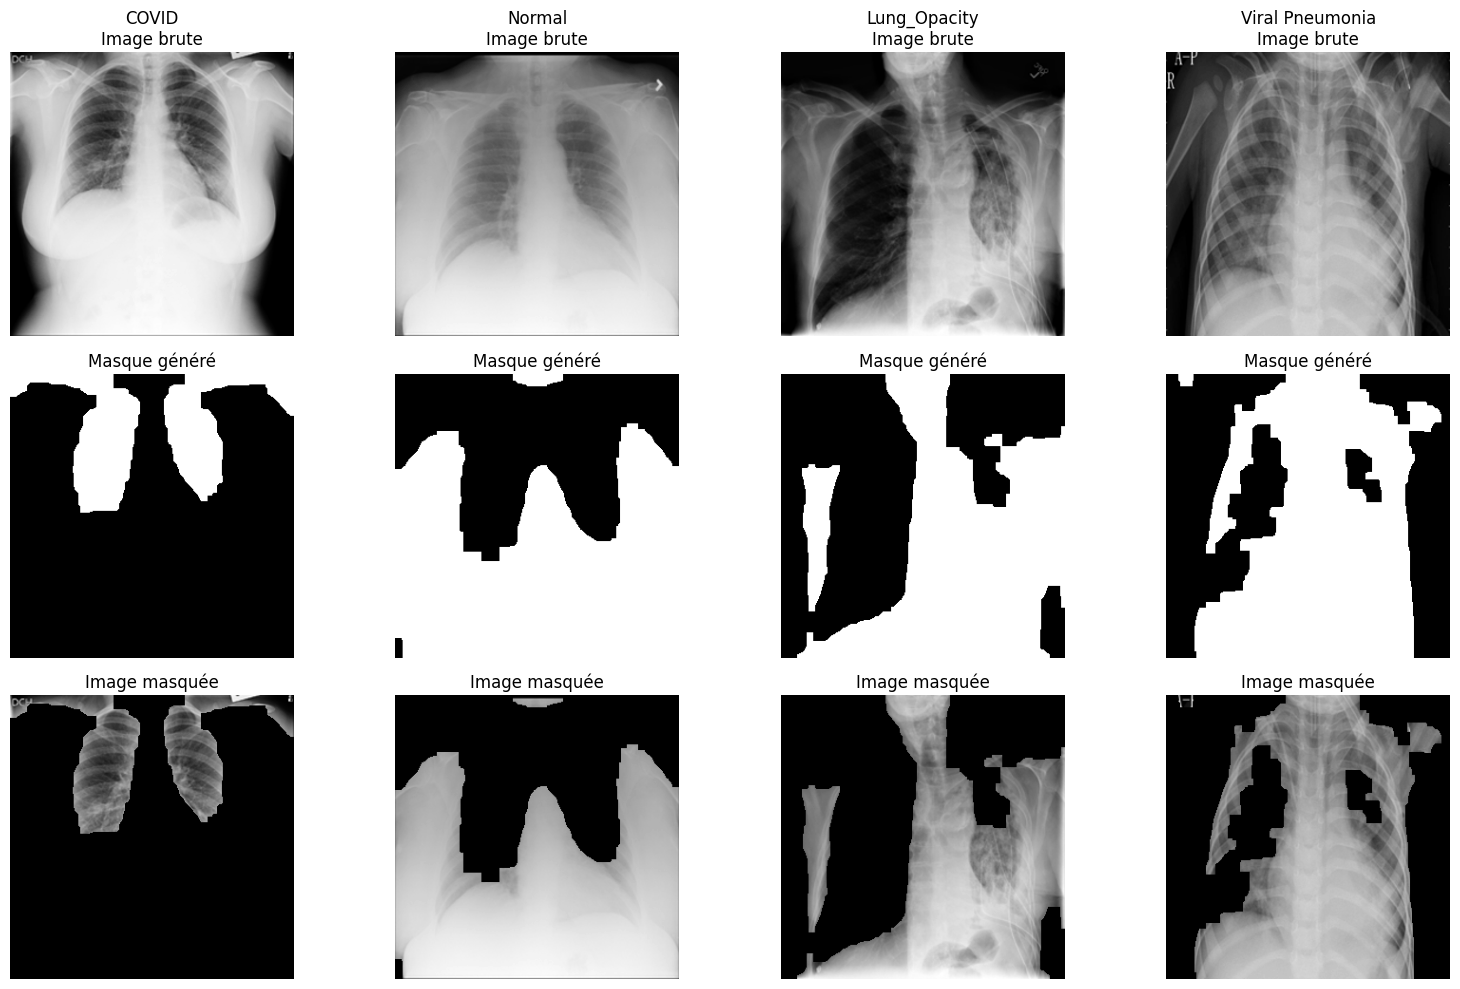

In [52]:
import random

random.seed(42)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for idx, class_name in enumerate(classes):
    
    images_dir = data_path / class_name / "images"
    masks_dir = auto_masks_path / class_name / "masks"
    
    img_path = random.choice(list(images_dir.glob("*.png")))
    mask_path = masks_dir / img_path.name
    
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    
    axes[0, idx].imshow(img, cmap="gray")
    axes[0, idx].set_title(f"{class_name}\nImage brute")
    axes[0, idx].axis("off")
    
    axes[1, idx].imshow(mask, cmap="gray")
    axes[1, idx].set_title("Masque généré")
    axes[1, idx].axis("off")
    
    axes[2, idx].imshow(masked_img, cmap="gray")
    axes[2, idx].set_title("Image masquée")
    axes[2, idx].axis("off")

plt.tight_layout()
plt.show()